<a href="https://colab.research.google.com/github/zyan-007/learning-stash-code/blob/main/neural_network_implementation_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

In [5]:
temp = np.array([240.6, 280.1, 262.5, 182.7, 193.5, 276.7, 150.8, 269.1, 265.6, 217.9, 193.9, 190.4, 187.0, 214.5, 223.2, 230.3, 294.3, 264.9, 240.2, 293.4, 181.2, 173.2, 238.8, 156.4, 155.2, 224.7, 217.6, 283.0, 241.2, 224.5, 222.0, 185.9, 151.7, 177.9, 250.3, 179.1, 203.6, 150.5, 270.4, 172.4, 188.8, 277.6, 223.9, 272.8, 242.8, 257.6, 163.3, 228.5, 223.6, 276.3, 202.4, 236.7, 158.6, 206.2, 196.8, 171.8, 268.4, 205.0, 291.9, 235.5, 237.7, 242.5, 248.1, 171.9, 213.8, 184.7, 208.4, 164.0, 290.3, 181.2, 247.4, 193.6, 276.7, 246.0, 169.1, 272.5, 287.0, 281.1, 232.6, 171.1, 177.9, 284.5, 230.1, 176.2, 278.2, 243.0, 232.6, 204.6, 209.6, 184.7, 155.5, 277.1, 217.8, 229.4, 196.7, 258.9, 153.7, 204.0, 154.4, 167.8])
duration = np.array([15.37, 14.13, 13.21, 13.59, 14.99, 12.88, 13.86, 14.23, 12.92, 13.58, 14.56, 15.14, 12.10, 15.23, 11.52, 14.51, 14.74, 12.05, 13.18, 14.76, 11.56, 14.01, 14.67, 13.55, 14.40, 12.41, 12.29, 12.95, 12.22, 12.88, 15.29, 13.79, 12.86, 12.59, 15.31, 13.28, 15.42, 13.56, 13.58, 15.09, 14.47, 13.82, 13.21, 15.01, 13.15, 15.19, 11.77, 13.22, 13.58, 15.30, 12.50, 14.72, 14.21, 14.37, 14.02, 15.39, 12.83, 13.09, 12.31, 11.70, 12.35, 15.16, 14.86, 11.95, 13.92, 13.42, 13.88, 14.14, 12.73, 15.35, 13.36, 14.01, 14.04, 12.24, 11.75, 13.15, 14.56, 14.76, 14.42, 11.95, 15.15, 14.71, 15.01, 13.59, 15.16, 11.69, 11.62, 11.58, 12.51, 12.49, 12.25, 13.77, 11.66, 13.86, 12.16, 14.21, 11.58, 12.74, 15.25, 13.65])
x_train = np.array([temp, duration])
x_train = x_train.T
x_train.shape

(100, 2)

In [35]:
y_train = np.array([0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [36]:
print(f"range: {np.ptp(x_train, axis=0)}")
norm_l = tf.keras.layers.Normalization(axis = -1)
norm_l.adapt(x_train)
x_norm = norm_l(x_train)
x_norm = x_norm.numpy()
print(f"range: {np.ptp(x_norm, axis=0)}")

range: [143.8   3.9]
range: [3.4320421 3.3246665]


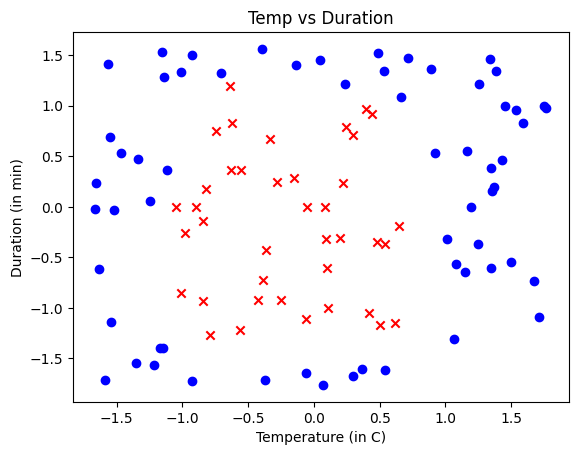

In [37]:
pos = y_train == 1
neg = y_train == 0

plt.scatter(x_norm[pos, 0], x_norm[pos, 1], marker = "x", color="r")
plt.scatter(x_norm[neg, 0], x_norm[neg, 1], marker = "o", color="b")
plt.xlabel("Temperature (in C)")
plt.ylabel("Duration (in min)")
plt.title("Temp vs Duration")

plt.show()

In [57]:
model = Sequential(
    [
        Input(shape=(2,)),
        Dense(units=3, activation="sigmoid", name="layer1"),
        Dense(units=1, activation="sigmoid", name="layer2")
    ]
)

In [58]:
x_norm_tiled = np.tile(x_norm, (1000, 1))
y_train_tiled = np.tile(y_train, (1000,))
print(x_norm_tiled.shape, y_train_tiled.shape)

(100000, 2) (100000,)


In [59]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer=tf.keras.optimizers.Adam(0.01))

In [60]:
w1, b1 = model.get_layer("layer1").get_weights()
w2, b2 = model.get_layer("layer2").get_weights()

print(f"w1: {w1}, b1: {b1}")
print(f"w2: {w2}, b2: {b2}")

w1: [[ 0.48510683  0.2488507   0.44793856]
 [-0.6537411   0.16405284 -0.7577523 ]], b1: [0. 0. 0.]
w2: [[-0.87246764]
 [-0.40044302]
 [-0.09748042]], b2: [0.]


In [61]:
model.fit(x_norm_tiled, y_train_tiled, epochs=10)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.3097
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1483
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.1118
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0856
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0692
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0577
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0491
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0425
Epoch 9/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0371
Epoch 10/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0328


In [62]:
w1, b1 = model.get_layer("layer1").get_weights()
w2, b2 = model.get_layer("layer2").get_weights()

print(f"w1: {w1}, b1: {b1}")
print(f"w2: {w2}, b2: {b2}")

w1: [[ 0.25354353  4.701648    3.5146177 ]
 [-1.82119     2.6604035  -1.7514484 ]], b1: [-2.0563204 -3.280924   3.0191033]
w2: [[-44.895683]
 [-32.279156]
 [ 33.72668 ]], b2: [-4.920746]


In [63]:
prediction = model.predict(x_norm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [78]:

y_hat = (prediction >= 0.5).astype(int)
y_hat = y_hat.reshape(1, 100)
y_hat

array([[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
        1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0]])

In [89]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (168.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28 (116.00 B)

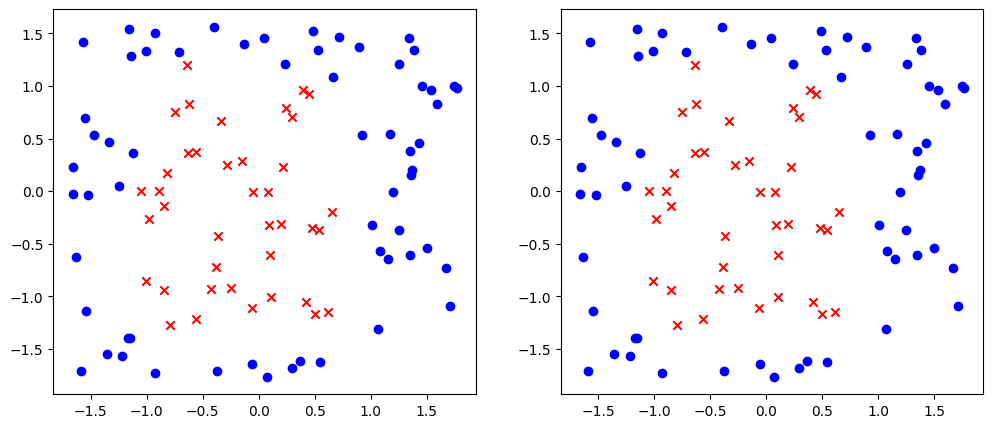

In [80]:
pos_t = y_hat[0] == 1
neg_t = y_hat[0] == 0

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(x_norm[pos, 0], x_norm[pos, 1], marker="x", color="r")
ax[0].scatter(x_norm[neg, 0], x_norm[neg, 1], marker="o", color="b")

ax[1].scatter(x_norm[pos_t, 0], x_norm[pos_t, 1], marker="x", color="r")
ax[1].scatter(x_norm[neg_t, 0], x_norm[neg_t, 1], marker="o", color="b")

plt.show()

In [83]:
  x_predict = np.array([[215, 13.0], [275, 14.5]])
  x_predict_norm = norm_l(x_predict)

  y_predict = (model.predict(x_predict_norm) >= 0.5).astype(int)
  print(y_predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[1]
 [0]]


In [88]:
print(y_train)
print(y_hat)
accuracy = (y_train == y_hat[0]).mean()
print(accuracy * 100)

[0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 1 0
 0 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 1 0 1
 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0]
[[0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 1
  0 0 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 1
  0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0]]
100.0
